# 03 · Exploratory Analysis

*German housing & rental price forecasting — reproducible pipeline.*

In [1]:
import sys, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
import pandas as pd, numpy as np, matplotlib.pyplot as plt

The decisive picture: **house prices boom and correct; rents barely move.** Two market segments with very different dynamics.

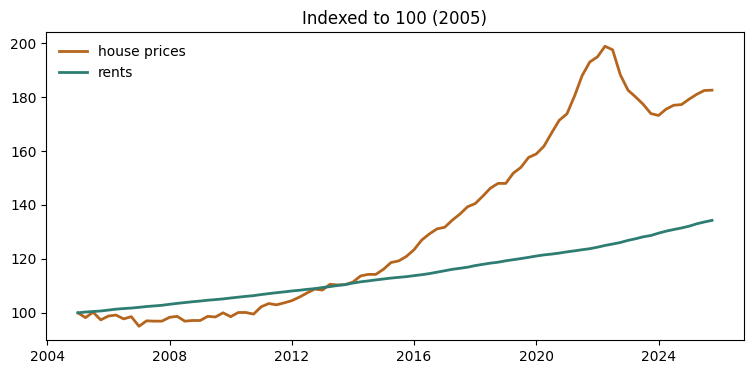

In [2]:
from data_loader import load_quarterly_panel
from preprocessing import clean_panel
clean = clean_panel(load_quarterly_panel())
b = clean.iloc[0]
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(clean['date'], clean['house_price']/b['house_price']*100, color='#B5651D', lw=2, label='house prices')
ax.plot(clean['date'], clean['rent_index']/b['rent_index']*100, color='#2E7D72', lw=2, label='rents')
ax.legend(frameon=False); ax.set_title('Indexed to 100 (2005)'); plt.show()

In [3]:
# QoQ returns: prices are volatile, rents tiny and almost always positive
pr = clean['house_price'].pct_change().dropna()*100
rr = clean['rent_index'].pct_change().dropna()*100
print(f'house price QoQ pct: mean {pr.mean():.2f} std {pr.std():.2f} min {pr.min():.2f}')
print(f'rent QoQ pct:        mean {rr.mean():.2f} std {rr.std():.2f} min {rr.min():.2f}')
print(f'share of quarters rents fell: {(rr < 0).mean():.3f}')

house price QoQ pct: mean 0.74 std 1.59 min -4.69
rent QoQ pct:        mean 0.36 std 0.11 min 0.19
share of quarters rents fell: 0.000


In [4]:
cc = ['house_price','rent_index','gdp_real','unemployment','long_rate','inflation_yoy','pop_growth_yoy']
clean[cc].corr().round(2)

,house_price,rent_index,gdp_real,unemployment,long_rate,inflation_yoy,pop_growth_yoy
house_price,1.00,0.95,0.89,-0.74,-0.50,0.51,0.28
rent_index,0.95,1.00,0.92,-0.83,-0.49,0.37,0.36
gdp_real,0.89,0.92,1.00,-0.90,-0.64,0.38,0.41
unemployment,-0.74,-0.83,-0.90,1.00,0.75,-0.22,-0.40
long_rate,-0.50,-0.49,-0.64,0.75,1.00,0.11,-0.48
inflation_yoy,0.51,0.37,0.38,-0.22,0.11,1.00,-0.11
pop_growth_yoy,0.28,0.36,0.41,-0.40,-0.48,-0.11,1.00
